# Quick-look for KUL-TN-20 simulations

This notebook can be used to have a quicklook at the that product for the simulations described in PLATO-PL-TN-0020. Note that the `LightCurve` class used to analyse the data assumes a identical structure of the data products as they are delivered on the KU Leuven FTP server.

### Setup notebook

In [57]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook6
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [58]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Load light curves for one star

In [79]:
# Load all data for a single star
sims = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/"

In [80]:
df = pd.read_feather(sims + '/P1/table_varsource_P1.ftr')
# Display stars with a planet
df0 = df[df['P_day'].notna()]
df0

,ID,Ms_Msun,Rs_Rsun,Teff_K,logg,Z,alpha,BV,logRHK,Prot_day,...,Mp_Mearth,Rp_Rearth,a_Rstar,P_day,t0_day,e,ip_deg,w_deg,u1,u2
1,000000002,1.279,1.540,6220.0,4.5,0.0,0.0,0.519483,-4.593498,5.494238,...,14.526625,3.9,102.716822,203.771797,161.759594,0.0,90.0,117.098169,0.438167,0.170268
4,000000005,1.401,1.731,6513.0,4.5,0.0,0.0,0.490000,-4.580409,2.988204,...,14.228421,3.9,118.089948,286.010924,140.043125,0.0,90.0,4.731793,0.412959,0.180919
5,000000006,1.402,1.866,6349.0,4.5,0.0,0.0,0.490000,-4.582876,3.990607,...,14.228421,3.9,63.267289,125.487071,-28.809921,0.0,90.0,149.226865,0.429054,0.171063
6,000000007,1.110,1.093,6127.0,4.5,0.0,0.0,0.545755,-4.605319,7.182874,...,14.831078,3.9,70.015495,73.602845,-105.857868,0.0,90.0,310.984555,0.444848,0.166471
11,000000012,1.306,1.719,6103.0,4.5,0.0,0.0,0.552842,-4.609129,5.987021,...,14.526625,3.9,58.547130,102.337946,-27.258986,0.0,90.0,101.232477,0.445388,0.167488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,000000992,1.016,1.205,5421.0,4.5,0.0,0.0,0.780137,-4.754350,26.411789,...,15.141913,3.9,60.209387,71.017212,-59.158028,0.0,90.0,153.049680,0.525510,0.126481
992,000000993,1.000,1.041,5634.0,4.5,0.0,0.0,0.698000,-4.686770,17.374218,...,14.526625,3.9,156.735582,241.413380,122.611374,0.0,90.0,61.525033,0.499336,0.137332
993,000000994,1.364,1.880,6165.0,4.5,0.0,0.0,0.535000,-4.600611,5.131181,...,14.228421,3.9,77.478167,174.355282,-141.625344,0.0,90.0,69.134445,0.443381,0.166262
998,000000999,1.141,1.312,5894.0,4.5,0.0,0.0,0.609610,-4.644565,9.666941,...,14.228421,3.9,46.966088,52.452922,-31.182680,0.0,90.0,358.900365,0.465920,0.158946


In [81]:
# Load light curve object
idir = f"{sims}/P5/lightcurve_without_maskupdate/000000002"
lcs = LightCurve(idir, mode="multi")
# To fetch a specific light curve, use instead:
# lc = LightCurve(f"{idir}/000000083/000000083_Ncam1.1_Q23.ftr")

In [82]:
# Unzip all compressed files for the same star
lcs.unpack()

In [83]:
# Fetch all feather filenames
filenames = lcs.files("ftr")
filenames

['/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000002/000000002_Ncam1.1_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000002/000000002_Ncam1.2_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000002/000000002_Ncam1.3_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000002/000000002_Ncam1.4_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000002/000000002_Ncam1.5_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000002/000000002_Ncam1.6_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000002/000000002_Ncam2.1_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_w

## Single N-CAM and Single Quarter

In [84]:
# Fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,index,time,flux,xc,yc,flux_cor
0,0,171072012.5,181359.256328,2.927974,2.675389,1.085152
1,1,171072037.5,182584.652775,2.923163,2.679349,1.085153
2,2,171072062.5,181474.333153,2.928438,2.675593,1.085150
3,3,171072087.5,182129.204447,2.927363,2.674614,1.085149
4,4,171072112.5,184706.393921,2.929805,2.663895,1.085148


In [85]:
# Get target star information
star = lc.star_info(lcs.files("cat")[0])
star

,Pmag,rOA,ncon,rcon,dmag,SPR
0,10.83,7.919439,4,5.216956,1.29,0.692767


In [86]:
# Get noise-less light curve
lc.varsource().head()

,time,spot,gran,puls,tran,sum
0,171072000.0,-428.431286,-52.485173,9.521939,0.0,-471.394520
1,171072025.0,-428.442265,-41.530959,13.622754,0.0,-456.350470
2,171072050.0,-428.453170,-27.697327,16.321104,0.0,-439.829392
3,171072075.0,-428.464000,-12.618214,17.604862,0.0,-423.477351
4,171072100.0,-428.474757,-0.931229,17.344704,0.0,-412.061283


<IPython.core.display.Javascript object>


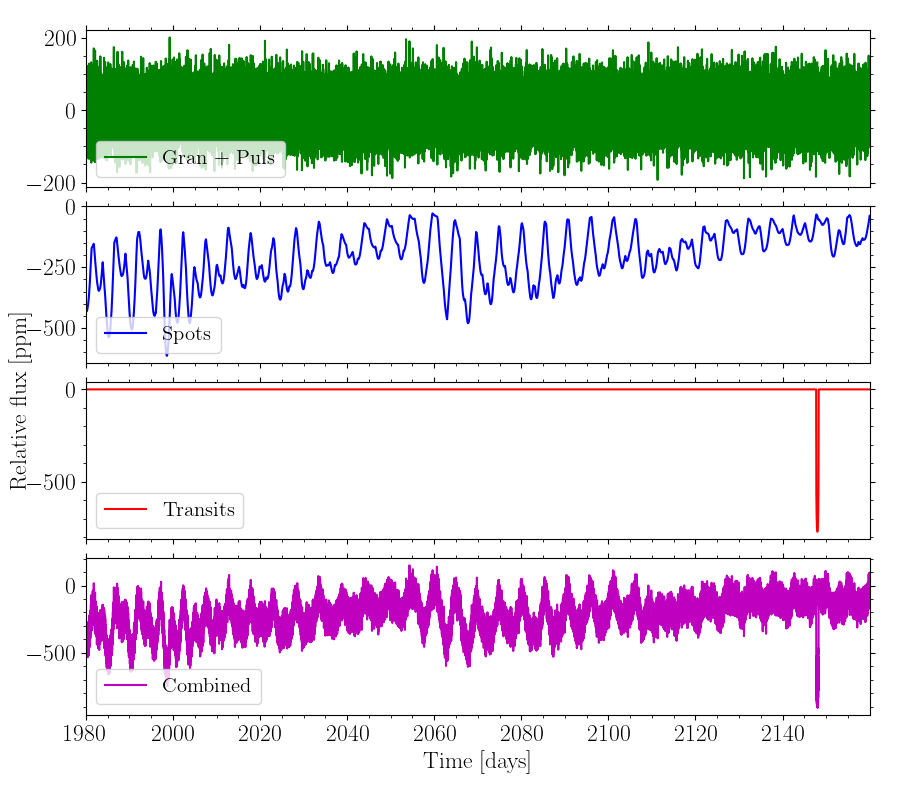

In [87]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

<IPython.core.display.Javascript object>


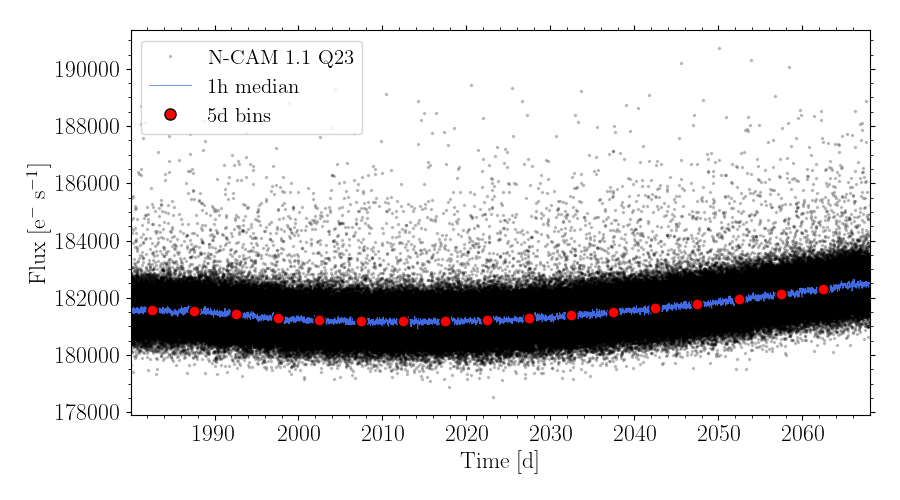

In [88]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=1);

<IPython.core.display.Javascript object>


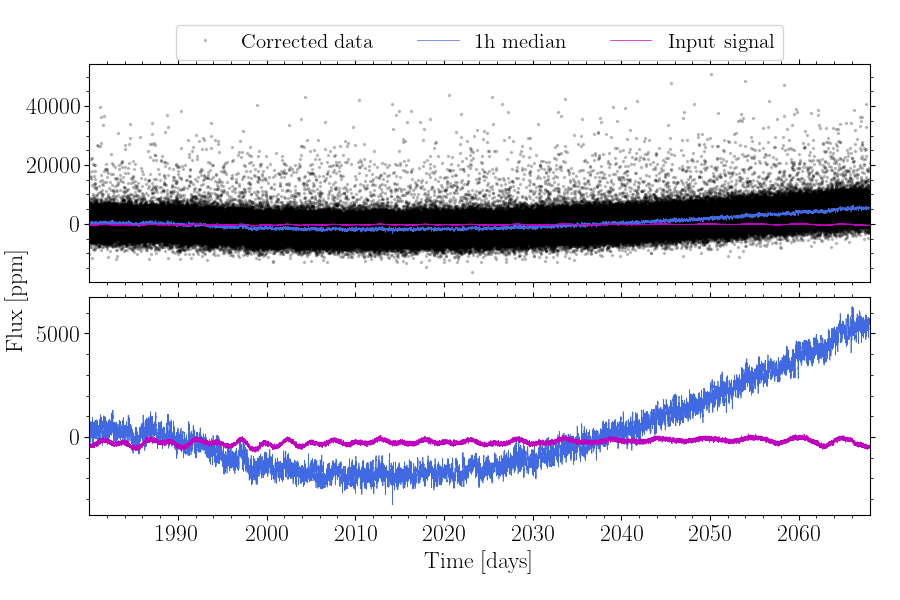

In [89]:
# Plot a quick O-C comparison plot 
fig, ax = lc.plot_oc();

<IPython.core.display.Javascript object>


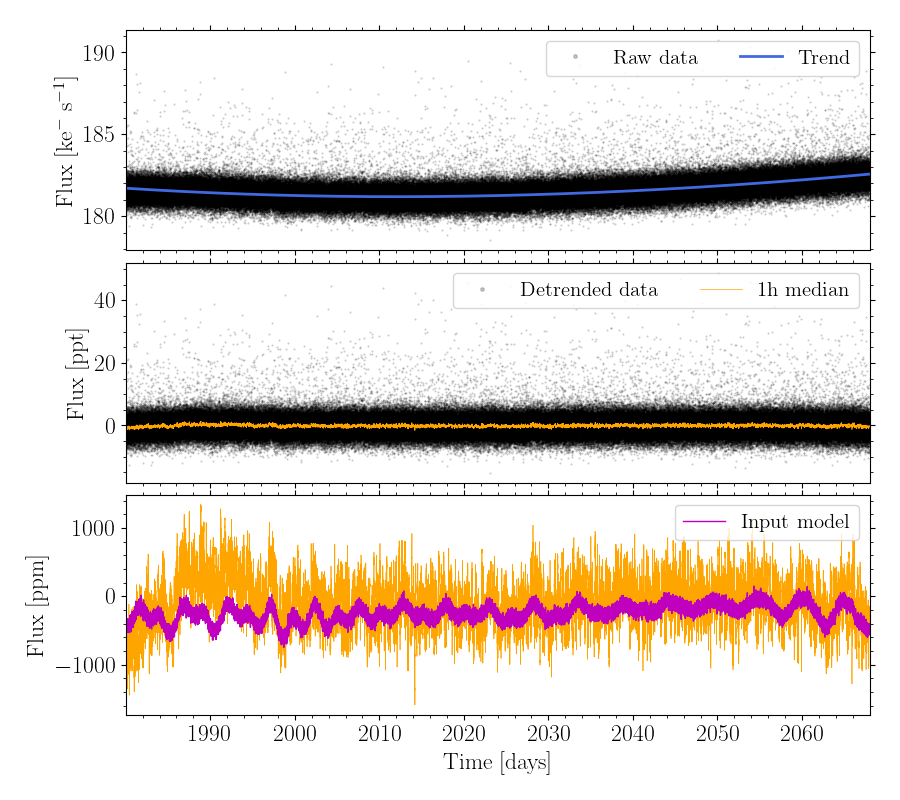

In [90]:
# Detrend light curve
lc.detrend(model='poly', degree=3, plot=True);

## All N-CAMs and Single Qaurter

<IPython.core.display.Javascript object>


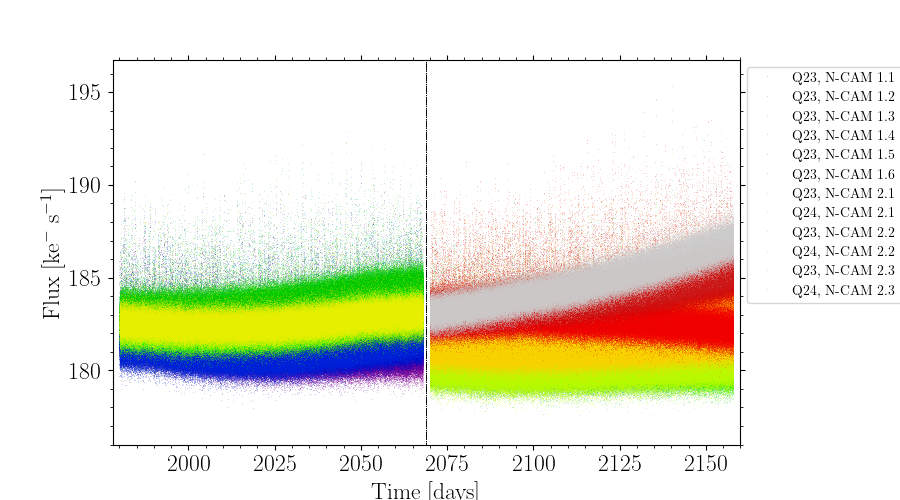

In [91]:
# Plot all light curves but for specific group, camera, or quarter
lcs.plot_multi(group=False, camera=False, quarter=False, flux_unit="e/s");

## Remember to remove unpacked files again!

In [93]:
# lcs.remove()